# Frekvensmodell for egen skade

Dette er en enkel Poisson-GLM for forventet antall egen-skader per
eksponeringsår. Notebooken bruker bare utviklingsårene 2022–2023; 2024
leses aldri.

In [16]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from IPython.display import display
from sklearn.metrics import mean_tweedie_deviance
from sklearn.model_selection import GroupKFold

from src_core_glm.glm_core import (
    cross_validate_glm,
    fit_glm,
    glm_spec,
    prepare_design_frame,
)
from src_frequency.frequency_diagnostics import (
    build_coefficient_table,
    build_glm_summary,
    build_rootogram_table,
    compare_candidate_coefficients,
    plot_oof_residuals_against_fitted,
    plot_oof_residuals_by_continuous_predictor,
    plot_rootogram,
    poisson_deviance_residuals,
)
from src_core_glm.model_data import (
    TRAIN_YEARS,
    build_development_frames,
    to_model_frame,
)
from src_core_glm.model_selection import run_backward_ablation, select_candidate_stage

SEED = 100
N_FOLDS = 5

## 1. Datagrunnlag

Vi avgrenser til kaskoproduktene og bygger bare utviklingsrammen. Manglende
verdier håndteres inne i hver CV-fold: median for tall og `MISSING` for
kategorier.

In [17]:
frames = build_development_frames()
development = frames["development"]

predictors = [
    "policy_type",
    "year",
    "driver_age",
    "log_vehicle_value",
    "performance_hp_per_tonne",
    "fuel_type",
    "circulation_area",
    "municipality_type",
    "payment_frequency",
    "business_type",
    "vehicle_brand_pooled",
    "seats",
]
model_columns = ["insured_id", "total_exposure", "property_claims", *predictors]
model_frame = to_model_frame(development, model_columns)
model_frame["claim_frequency"] = (
    model_frame["property_claims"] / model_frame["total_exposure"]
)

display(frames["cleaning_log"])
display(
    pd.DataFrame(
        {
            "poliseaar": [len(model_frame)],
            "eksponeringsaar": [model_frame["total_exposure"].sum()],
            "skader": [model_frame["property_claims"].sum()],
            "utviklingsaar": [", ".join(map(str, TRAIN_YEARS))],
        }
    ).round(2)
)

,step,affected_rows,result
0,"Kontroll av skjema, kategorikoder og unik poli...",0,Bestått
1,Fjerning av omkringliggende mellomrom i tekstfelt,0,Standardisert
2,Ikke-positiv power_to_weight_ratio satt til ma...,1,Standardisert
3,Manglende total- og ansvarseksponering satt ti...,1,Korrigert
4,Rader slettet eller imputert,0,Ingen


,poliseaar,eksponeringsaar,skader,utviklingsaar
0,55246,37126.01,9989,"2022, 2023"


## 2. Validering

Fem gruppefolder på `insured_id` måler hvor godt modellen generaliserer til
andre forsikrede. Samme forsikrede kan ikke ligge i både trening og
validering. Vi bruker ikke tidsfolden 2022 → 2023: den hørte til den gamle,
store kandidatstigen og brukes ikke når modellen er forhåndsdefinert.

In [18]:
group_kfold = GroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
cv_folds = [
    {
        "fold": f"gruppe_{number + 1}",
        "train_index": model_frame.index[train_positions],
        "val_index": model_frame.index[val_positions],
    }
    for number, (train_positions, val_positions) in enumerate(
        group_kfold.split(model_frame, groups=model_frame["insured_id"])
    )
]

## 3. Modellspesifikasjoner

For begge modeller gjelder

$$N_i \sim \operatorname{Poisson}(e_i\lambda_i), \qquad
\log \lambda_i = \beta_0 + \sum_j \beta_j x_{ij}.$$

Her er $N_i$ skadeantall og $e_i$ eksponering. Vi starter med hele den
faglig valgte kjernen og bygger deretter modellen i tre korte trinn:
splines, kjøretøyopplysninger og én produkt × alder-interaksjon.

In [19]:
CORE_PREDICTORS = [
    "policy_type",
    "year",
    "driver_age",
    "log_vehicle_value",
    "performance_hp_per_tonne",
    "fuel_type",
    "circulation_area",
    "municipality_type",
    "payment_frequency",
    "business_type",
]
frequency_settings = {
    "y": "claim_frequency",
    "data": model_frame,
    "family": sm.families.Poisson(link=sm.families.links.Log()),
    "weight": "total_exposure",
    "power": 1,
}


def build_frequency_specification(name, predictors, spline_terms=(), interaction=False):
    """Bygg én frekvensspesifikasjon; splines og interaksjon er formelledd."""
    spline_map = dict(spline_terms)
    terms = [
        f"cr({column}, df={spline_map[column]}, constraints='center')"
        if column in spline_map
        else column
        for column in predictors
    ]
    if interaction:
        terms.append("C(policy_type, Treatment('COMP_E')):driver_age")
    return glm_spec(name, terms, required_columns=predictors, **frequency_settings)

## 4. Sammenligning og valg

Poisson-deviance beregnes out-of-fold og eksponeringsvekter hver rad.
En kandidat velges bare når tre kriterier er oppfylt: lavere samlet
OOF-deviance, bedre deviance i minst fire folder og gyldig tilpasning i alle
fem folder. Dette er hele seleksjonsregelen.

In [20]:
specifications = {
    "kjernevariabler": build_frequency_specification(
        "kjernevariabler", CORE_PREDICTORS
    )
}
cv_results = {
    "kjernevariabler": cross_validate_glm(
        specifications["kjernevariabler"], model_frame, cv_folds
    )
}


def select_stage(parent_name, candidate_names):
    """Bruk den felles treleddsregelen for dette frekvensdatasettet."""
    return select_candidate_stage(
        cv_results,
        parent_name,
        candidate_names,
        model_frame["claim_frequency"],
        model_frame["total_exposure"],
        power=1,
    )

### 4.1 Funksjonsform

Hver kontinuerlige kjernevariabel får én naturlig spline som utfordrer den
lineære formen. Bare den beste kvalifiserte kandidaten går videre.

In [21]:
spline_labels = {
    "driver_age": "alder_spline",
    "log_vehicle_value": "bilverdi_spline",
    "performance_hp_per_tonne": "ytelse_spline",
}
spline_candidates = {
    label: build_frequency_specification(label, CORE_PREDICTORS, [(column, 3)])
    for column, label in spline_labels.items()
}
specifications.update(spline_candidates)
cv_results.update(
    {name: cross_validate_glm(spec, model_frame, cv_folds) for name, spec in spline_candidates.items()}
)
spline_model_name, spline_selection = select_stage("kjernevariabler", list(spline_candidates))
display(spline_selection.round(4))

,oof_deviance,lavere_oof,bedre_4_av_5,gyldig_i_alle_folder,cv_feil
modell,,,,,
alder_spline,1.1218,True,True,True,
bilverdi_spline,1.1239,False,False,True,
ytelse_spline,1.1233,False,False,True,


### 4.2 Kjøretøyopplysninger

Bilmerke og antall seter testes hver for seg mot modellen fra
funksjonsformsteget. Ingen ekstra kriterier brukes.

In [22]:
chosen_terms = []
if spline_model_name != "kjernevariabler":
    chosen_column = next(
        column for column, label in spline_labels.items() if label == spline_model_name
    )
    chosen_terms = [(chosen_column, 3)]

vehicle_candidates = {
    "kjerne_med_bilmerke": build_frequency_specification(
        "kjerne_med_bilmerke", CORE_PREDICTORS + ["vehicle_brand_pooled"], chosen_terms
    ),
    "kjerne_med_seter": build_frequency_specification(
        "kjerne_med_seter", CORE_PREDICTORS + ["seats"], chosen_terms
    ),
}
specifications.update(vehicle_candidates)
cv_results.update(
    {name: cross_validate_glm(spec, model_frame, cv_folds) for name, spec in vehicle_candidates.items()}
)
additive_model_name, vehicle_selection = select_stage(spline_model_name, list(vehicle_candidates))
display(vehicle_selection.round(4))

,oof_deviance,lavere_oof,bedre_4_av_5,gyldig_i_alle_folder,cv_feil
modell,,,,,
kjerne_med_bilmerke,1.1214,True,False,True,
kjerne_med_seter,1.1217,True,True,True,


### 4.3 Produkt × alder

Én forhåndsvalgt interaksjon testes ved å legge leddet direkte til
GLM-formelen. Det er ingen egen kodevei, egne kontroller eller plott.

In [23]:
interaction_candidate = build_frequency_specification(
    "kjerne_med_produkt_alder_interaksjon",
    specifications[additive_model_name]["required_columns"],
    chosen_terms,
    interaction=True,
)
specifications[interaction_candidate["name"]] = interaction_candidate
cv_results[interaction_candidate["name"]] = cross_validate_glm(
    interaction_candidate, model_frame, cv_folds
)
selected_model_name, interaction_selection = select_stage(
    additive_model_name, [interaction_candidate["name"]]
)
display(interaction_selection.round(4))
selected_specification = specifications[selected_model_name]
print(f"Valgt frekvensmodell: {selected_model_name}")

/workspaces/MotorForsikring/.venv/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1486: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  wls_results = wls_model.fit(method=wls_method2)
/workspaces/MotorForsikring/.venv/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1486: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  wls_results = wls_model.fit(method=wls_method2)
/workspaces/MotorForsikring/.venv/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1486: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  wls_results = wls_model.fit(method=wls_method2)
/workspaces/MotorForsikring/.venv/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1486: SingularMatrixWarning: The design matrix is rank-deficie

,oof_deviance,lavere_oof,bedre_4_av_5,gyldig_i_alle_folder,cv_feil
modell,,,,,
kjerne_med_produkt_alder_interaksjon,NaN,False,True,False,gruppe_1: rangsvikt (18 av 19 kolonner); grupp...


Valgt frekvensmodell: kjerne_med_seter


### 4.4 Ablasjon

Vi prøver å fjerne én variabel om gangen fra modellen som nå er valgt. For en
kandidatvariabel $x_j$ er modellen $\log\lambda_i=\eta_i-\beta_jx_{ij}$.
En fjerning beholdes bare når den oppfyller de samme tre CV-kriteriene som
resten av stigen. Prosessen gjentas til ingen variabel kan tas bort.

In [24]:
includes_interaction = selected_model_name == "kjerne_med_produkt_alder_interaksjon"


def build_ablation_candidate(current_name, column):
    predictors = specifications[current_name]["required_columns"]
    remaining = [item for item in predictors if item != column]
    terms = [item for item in chosen_terms if item[0] in remaining]
    name = f"{current_name}_uten_{column}"
    return build_frequency_specification(name, remaining, terms, includes_interaction)


protected_predictors = {"policy_type", "year"}
if includes_interaction:
    protected_predictors.add("driver_age")
final_model_name, removed_predictors, ablation_tables = run_backward_ablation(
    selected_model_name,
    specifications,
    cv_results,
    protected_predictors,
    build_ablation_candidate,
    lambda specification: cross_validate_glm(specification, model_frame, cv_folds),
    select_stage,
)
for ablation_table in ablation_tables:
    display(ablation_table.round(4))
selected_specification = specifications[final_model_name]
print("Fjernet i ablasjon:", ", ".join(removed_predictors) or "ingen")

,oof_deviance,lavere_oof,bedre_4_av_5,gyldig_i_alle_folder,cv_feil,fjernet_variabel
modell,,,,,,
kjerne_med_seter_uten_driver_age,1.1237,False,False,True,,driver_age
kjerne_med_seter_uten_log_vehicle_value,1.1231,False,False,True,,log_vehicle_value
kjerne_med_seter_uten_performance_hp_per_tonne,1.1217,True,False,True,,performance_hp_per_tonne
kjerne_med_seter_uten_fuel_type,1.1226,False,False,True,,fuel_type
kjerne_med_seter_uten_circulation_area,1.1233,False,False,True,,circulation_area
kjerne_med_seter_uten_municipality_type,1.1216,True,False,True,,municipality_type
kjerne_med_seter_uten_payment_frequency,1.1235,False,False,True,,payment_frequency
kjerne_med_seter_uten_business_type,1.1264,False,False,True,,business_type
kjerne_med_seter_uten_seats,1.1218,False,False,True,,seats


Fjernet i ablasjon: ingen


## 5. Koeffisienttabell for modellen under vurdering

Den automatiske ablasjonsregelen beholdt `municipality_type`, men kandidaten
`kjerne_med_seter_uten_municipality_type` vises her før et endelig valg tas.
Koeffisientene estimeres på alle utviklingsdata og beskriver sammenhenger i
dette datasettet, ikke kausale effekter.

In [25]:
review_model_name = final_model_name
assert review_model_name in specifications
review_specification = specifications[review_model_name]
final_design = prepare_design_frame(
    model_frame, model_frame, review_specification["required_columns"]
)
final_fit = fit_glm(
    review_specification,
    final_design,
    cluster_groups=final_design["insured_id"],
)
final_summary = build_glm_summary(review_specification, final_fit, final_design)
final_coefficients = build_coefficient_table(final_fit)

display(final_summary.to_frame().T.round(4))
display(final_coefficients.round(3))

,formel,familie,rader,parametere,deviance,d2,balanse
kjerne_med_seter,"claim_frequency ~ C(policy_type, Treatment('CO...",Poisson,55246,17,1.119482,0.099567,1.0


,koeffisient,standardfeil,z,p_verdi,ki_95_lav,ki_95_høy,relativitet
Intercept,-4.672,0.569,-8.214,0.000,-5.787,-3.558,0.009
"C(policy_type, Treatment('COMP_E'))[T.COMP_N]",1.292,0.033,38.738,0.000,1.226,1.357,3.638
"C(year, Treatment(2023))[T.2022]",-0.081,0.036,-2.233,0.026,-0.153,-0.010,0.922
"C(fuel_type, Treatment('D'))[T.G]",-0.173,0.047,-3.712,0.000,-0.264,-0.082,0.841
"C(fuel_type, Treatment('D'))[T.MISSING]",0.011,0.139,0.081,0.936,-0.261,0.283,1.011
"C(circulation_area, Treatment('U'))[T.R]",-0.174,0.034,-5.177,0.000,-0.240,-0.108,0.840
"C(municipality_type, Treatment('I'))[T.C]",-0.043,0.037,-1.162,0.245,-0.115,0.029,0.958
"C(municipality_type, Treatment('I'))[T.IS]",-0.014,0.082,-0.174,0.862,-0.175,0.147,0.986
"C(payment_frequency, Treatment('A'))[T.Q]",0.366,0.063,5.818,0.000,0.243,0.490,1.442
"C(payment_frequency, Treatment('A'))[T.S]",0.098,0.050,1.981,0.048,0.001,0.196,1.103


In [26]:
def summarize_candidate(name, result):
    """Samle sammenlignbare OOF-metrikker for én kandidat."""
    oof_deviance = mean_tweedie_deviance(
        model_frame["claim_frequency"],
        result["oof"],
        sample_weight=model_frame["total_exposure"],
        power=1,
    )
    scores = result["scores"]
    null_deviance = np.average(scores["val_null_deviance"], weights=scores["val_weight"])
    predicted = (result["oof"] * model_frame["total_exposure"]).sum()
    actual = model_frame["property_claims"].sum()
    return {
        "modell": name,
        "oof_deviance": oof_deviance,
        "oof_d2": 1 - oof_deviance / null_deviance,
        "oof_balanse": predicted / actual,
        "parametere": int(scores["n_params"].mean()),
    }

## 6. Stabilitet i koeffisientene

Tabellen sammenligner modellen under vurdering med de to nærmeste kandidatene
målt ved OOF-deviance. Bare koeffisienter som finnes i den endelige modellen
vises. En liten endring tyder på at estimatet er robust mot disse alternative
spesifikasjonene; den er ikke et mål på statistisk usikkerhet.

In [27]:
candidate_metrics = pd.DataFrame(
    [
        summarize_candidate(name, result)
        for name, result in cv_results.items()
        if result["valid"] and result["oof"].notna().all()
    ]
).set_index("modell")
nearest_names = [review_model_name] + [
    name
    for name in candidate_metrics.sort_values("oof_deviance").index
    if name != review_model_name
][:2]

candidate_fits = {}
for name in nearest_names:
    design = prepare_design_frame(
        model_frame, model_frame, specifications[name]["required_columns"]
    )
    candidate_fits[name] = fit_glm(specifications[name], design)

coefficient_stability = compare_candidate_coefficients(
    candidate_fits, review_model_name
)
display(coefficient_stability.round(3))

,kjerne_med_seter,kjerne_med_bilmerke,endring_fra_kjerne_med_seter_kjerne_med_bilmerke,kjerne_med_seter_uten_municipality_type,endring_fra_kjerne_med_seter_kjerne_med_seter_uten_municipality_type
Intercept,-4.672,-4.068,0.604,-4.685,-0.013
"C(policy_type, Treatment('COMP_E'))[T.COMP_N]",1.292,1.290,-0.001,1.296,0.004
"C(year, Treatment(2023))[T.2022]",-0.081,-0.083,-0.001,-0.083,-0.001
"C(fuel_type, Treatment('D'))[T.G]",-0.173,-0.173,0.000,-0.175,-0.002
"C(fuel_type, Treatment('D'))[T.MISSING]",0.011,-0.017,-0.028,0.008,-0.004
"C(circulation_area, Treatment('U'))[T.R]",-0.174,-0.171,0.003,-0.171,0.003
"C(municipality_type, Treatment('I'))[T.C]",-0.043,-0.041,0.002,NaN,NaN
"C(municipality_type, Treatment('I'))[T.IS]",-0.014,-0.007,0.007,NaN,NaN
"C(payment_frequency, Treatment('A'))[T.Q]",0.366,0.374,0.008,0.367,0.000
"C(payment_frequency, Treatment('A'))[T.S]",0.098,0.096,-0.003,0.097,-0.002


## 7. OOF-diagnostikk av Poisson-GLM-en

Residualene bygger på prediksjoner fra folden der poliseåret ikke inngikk i
tilpasningen. LOWESS-kurvene er visuelle hjelpemidler, ikke hypotesetester.

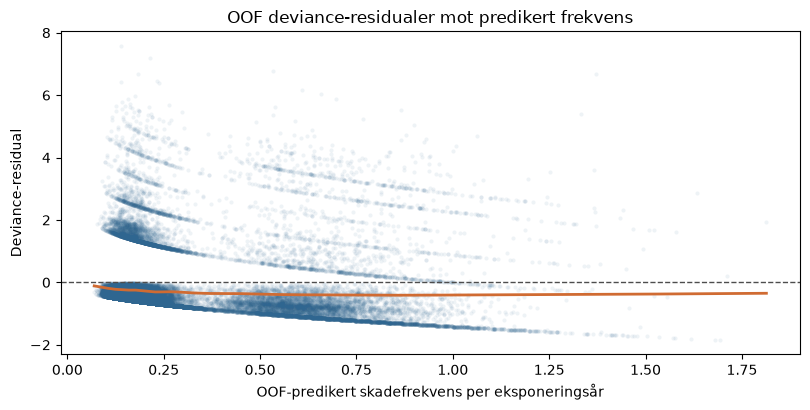

In [28]:
oof_frequency = cv_results[review_model_name]["oof"]
assert oof_frequency.index.equals(model_frame.index)
assert oof_frequency.notna().all()
oof_expected_claims = oof_frequency * model_frame["total_exposure"]
oof_residuals = poisson_deviance_residuals(
    model_frame["property_claims"], oof_expected_claims
)
oof_fitted_figure = plot_oof_residuals_against_fitted(oof_frequency, oof_residuals)

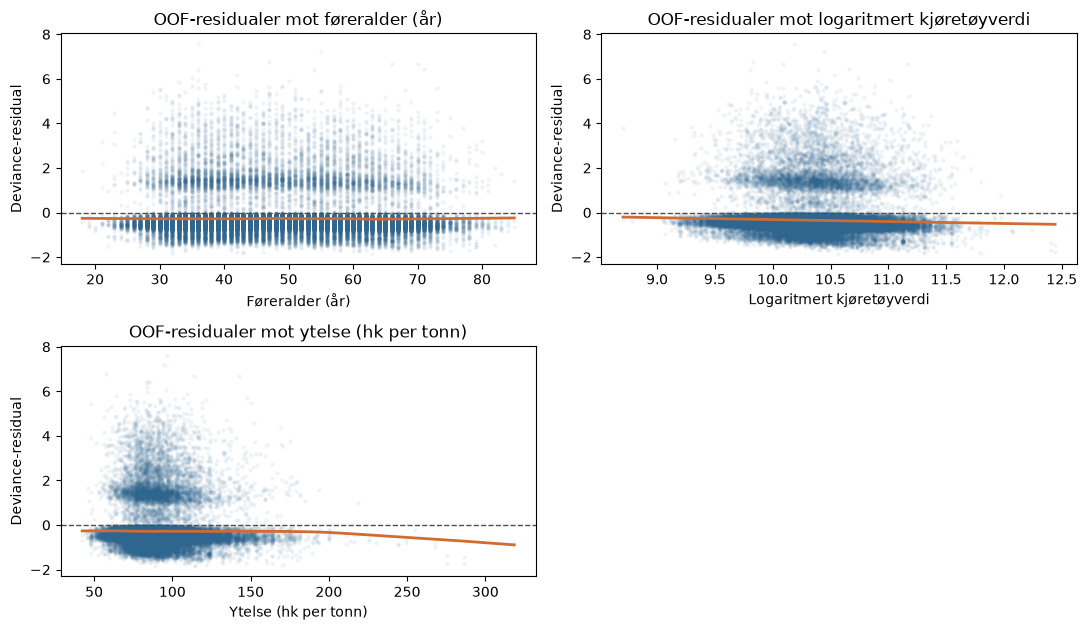

In [29]:
continuous_predictors = [
    predictor
    for predictor in ["driver_age", "log_vehicle_value", "performance_hp_per_tonne"]
    if predictor in review_specification["required_columns"]
]
oof_predictor_figure = plot_oof_residuals_by_continuous_predictor(
    model_frame, continuous_predictors, oof_residuals
)

## 8. Manuell modellsammenligning

Tabellen er en fast, lesbar sammenligning av relevante spesifikasjoner med
gyldige OOF-prediksjoner.
Den automatiske seleksjonsstigen er fortsatt grunnlaget for modellvalget;
denne tabellen er laget for å gjøre modellforskjellene enkle å vurdere
manuelt. OOF-metrikkene, ikke koeffisientene fra full-fit, er sammenlignbare.

In [30]:
MANUAL_COMPARISON_MODELS = [
    "kjernevariabler",
    "alder_spline",
    "kjerne_med_seter",
    "kjerne_med_produkt_alder_interaksjon",
]
available_comparison_models = [
    name for name in MANUAL_COMPARISON_MODELS if name in candidate_metrics.index
]
decision_table = candidate_metrics.loc[available_comparison_models].copy()
decision_table.insert(
    0,
    "spesifikasjon",
    [specifications[name]["formula"] for name in available_comparison_models],
)
decision_table.index.name = "modell"
display(decision_table.round(4))

,spesifikasjon,oof_deviance,oof_d2,oof_balanse,parametere
modell,,,,,
kjernevariabler,"claim_frequency ~ C(policy_type, Treatment('CO...",1.1232,0.0966,0.9997,14
alder_spline,"claim_frequency ~ C(policy_type, Treatment('CO...",1.1218,0.0978,0.9997,16
kjerne_med_seter,"claim_frequency ~ C(policy_type, Treatment('CO...",1.1217,0.0978,0.9997,17


**Begrensning.** CV-scoren er en utviklingsscore og den enkle valgregelen er
bevisst laget for presentasjon, ikke for maksimal modelloptimalisering.
Modellen må være låst før en senere, separat evaluering på 2024.

## 9. Statsmodels-sammendrag

Det innebygde sammendraget beholdes som fullstendig referanse for den valgte
modellen. Koeffisienttabellen over er den kompakte presentasjonen.

In [33]:
display(final_fit.summary())

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:        claim_frequency   No. Observations:                55246
Model:                            GLM   Df Residuals:                    55229
Model Family:                 Poisson   Df Model:                           16
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -26675.
Date:                Fri, 18 Sep 2026   Deviance:                       41562.
Time:                        20:58:40   Pearson chi2:                 1.13e+05
No. Iterations:                     6   Pseudo R-squ. (CS):            0.07982
Covariance Type:              cluster                                         
=================================================================================================================
                                                    coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------
Intercept                                        -4.6724      0.569     -8.214      0.000      -5.787      -3.558
C(policy_type, Treatment('COMP_E'))[T.COMP_N]     1.2915      0.033     38.738      0.000       1.226       1.357
C(year, Treatment(2023))[T.2022]                 -0.0814      0.036     -2.233      0.026      -0.153      -0.010
C(fuel_type, Treatment('D'))[T.G]                -0.1730      0.047     -3.712      0.000      -0.264      -0.082
C(fuel_type, Treatment('D'))[T.MISSING]           0.0112      0.139      0.081      0.936      -0.261       0.283
C(circulation_area, Treatment('U'))[T.R]         -0.1739      0.034     -5.177      0.000      -0.240      -0.108
C(municipality_type, Treatment('I'))[T.C]        -0.0428      0.037     -1.162      0.245      -0.115       0.029
C(municipality_type, Treatment('I'))[T.IS]       -0.0143      0.082     -0.174      0.862      -0.175       0.147
C(payment_frequency, Treatment('A'))[T.Q]         0.3663      0.063      5.818      0.000       0.243       0.490
C(payment_frequency, Treatment('A'))[T.S]         0.0985      0.050      1.981      0.048       0.001       0.196
C(business_type, Treatment('NB'))[T.P]            0.3048      0.036      8.493      0.000       0.234       0.375
cr(driver_age, df=3, constraints='center')[0]    -0.3862      0.130     -2.980      0.003      -0.640      -0.132
cr(driver_age, df=3, constraints='center')[1]    -0.0819      0.065     -1.252      0.211      -0.210       0.046
cr(driver_age, df=3, constraints='center')[2]     0.4411      0.183      2.416      0.016       0.083       0.799
log_vehicle_value                                 0.2910      0.064      4.572      0.000       0.166       0.416
performance_hp_per_tonne                          0.0012      0.001      0.957      0.339      -0.001       0.004
seats                                            -0.0256      0.021     -1.209      0.227      -0.067       0.016
=================================================================================================================
"""

## 10. OOF-rootogram

Det hengende rootogrammet sammenligner observert skadeantall med summen av
de OOF-predikerte Poisson-sannsynlighetene. Søyler som avviker fra den
forventede linjen viser hvor frekvensfordelingen ikke treffes helt.

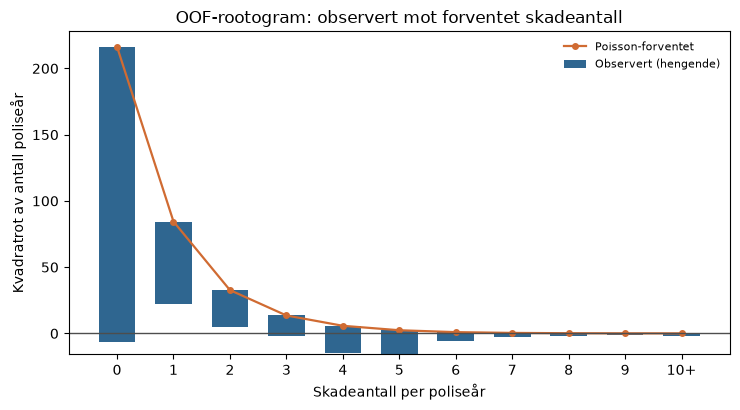

In [32]:
rootogram_table = build_rootogram_table(
    model_frame["property_claims"], oof_expected_claims
)
rootogram_figure = plot_rootogram(rootogram_table)